# DATA SOURCE:
+ https://github.com/nflverse/nfldata

# Comparison:
+ https://www.nfeloapp.com/games/nfl-model-performance/#:~:text=About,models%20available%20on%20the%20internet

# Import

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import missingno as msno

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, fbeta_score, make_scorer, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [6]:
# Get notebook directory
os.getcwd()
# Set path to main directory of the project
path = os.path.normpath(os.getcwd() + os.sep + os.pardir)

# Reading in data and creating DataFrame
df = pd.read_csv(path + "/games.csv", sep=",")
# Set max columns to 200, so df.head() shows all(max 200) columns    
pd.set_option("display.max_columns", 200) 
# Rename qb columns
df = df.rename(columns={"away_qb_name": "away_qb", "home_qb_name": "home_qb"})
# Display head so we can so what we are working with and make sure the import went right
display(df.head())

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb,home_qb,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [3]:
# Inserting missing data, for prediction, about future Conference Championship Games
# KC @ BA
kc_bal = {"temp": 44,
          "wind": 4,
          "away_qb": "Patrick Mahomes",
          "home_qb": "Lamar Jackson",
          "referee": "Shawn Smith"}
# DET @ SF
det_sf = {"temp": 66,
          "wind": 2,
          "away_qb": "Jared Goff",
          "home_qb": "Brock Purdy",
          "referee": "Clete Blakeman"}
for key, value in kc_bal.items():
    df.loc[6703, key] = value
for key, value in det_sf.items():
    df.loc[6704, key] = value

# Functions

In [4]:
# Cleaning function
def clean_df(df, start_season=2000):
    """Returns cleaned DataFrame.

    - drops unused columns
    - creates new columns
    - changes dtype of columns where necessary
    - imputation of NaNs
    
    Args:
    df (pd.DataFrame) : uncleaned DataFrame
    start_season (int): sets the starting season for the DataFrame = 2000
    
    Returns:
    df (pd.DataFrame) : cleaned DataFrame
    
    """
    # ---------- DROP COLUMNS AND ROWS ---------- 
    # We will drop additional columns later with an extra function, because we need them to create additional features
    # Drop bet related columns
    # We also drop the scores, totals and results after creating our target "win".
    df = df.drop(columns=['away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
                          'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])
    # Drop double columns
    df = df.drop(columns=['away_qb_id', 'home_qb_id', 'stadium_id'])
    
    # Select starting season via start_season
    # All missing gametimes are in the '99 season, so we set start_seasons default to 2000, to drop atleast the 1999 season
    df = df.loc[df['season'] >= start_season, :]
    df = df.reset_index(drop=True)
    
    # ---------- CREATE NEW COLUMNS ---------- 
    # Check the current date
    now = datetime.now()
    # Fill NaNs in gametime, so we can convert to datetime
    df["gametime"] = df["gametime"].fillna("11:11")
    # Convert gameday and gametime to datetime 
    df['gameday'] = pd.to_datetime(df['gameday'])
    df['gametime'] = pd.to_datetime(df['gametime'], format="%H:%M")
    # Extract hour and minute from the gametime
    df["starting_hour"] = df.loc[:, "gametime"].dt.hour
    # Convert gametime to string only showing "HH:MM"
    df['gametime'] = df['gametime'].dt.strftime("%H:%M")
    # Combine both columns to get gameday + gametime as one, so we can compare it to now
    df['datetime'] = pd.to_datetime(df['gameday'].astype(str) + ' ' + df['gametime'])
    # Replace our imputation value with NaNs again
    df["gametime"] = df["gametime"].replace("11:11:00", np.nan)
    # Filter rows where "datetime" is greater than "now" to drop future games
    #df = df[df['datetime'] < now]
    # Create month column
    df["month"] = df["gameday"].dt.month
    # Create target column "win"
    # np.where(condition = df["result"] > 0, then = 1, else = 0)
    df["win"] = np.where(df["result"] > 0, 1, 0)

    # ---------- IMPUTATION OF TEAMS ---------- 
    # Merge old with new team names
    # OLD - NEW Team name
    # OAK (Oakland Raiders) - LV (Las Vegas Raiders) 
    # SD (San Diego Chargers) - LAC (Los Angeles Chargers)
    # STL (St. Louis Rams) - LA (Los Angeles Rams)
    team_cols = ["away_team", "home_team"]
    for col in team_cols:
        df.loc[:, col] = df.loc[:, col].replace({"OAK": "LV", 
                                                "SD": "LAC", 
                                                "STL": "LA"})
      
    # ---------- IMPUTATION OF SURFACE ---------- 
    # Everything else than grass is synthetic or hybrid grass
    # Combine all synthetic and hybrid under 'synthetic'
    # Combine both grass
    df.loc[:, "surface"] = df.loc[:, "surface"].replace(["fieldturf", "astroturf", "sportturf", "matrixturf", "astroplay", "a_turf", "dessograss"], "synthetic")
    df.loc[:, "surface"] = df.loc[:, "surface"].replace("grass ", "grass")

    # Get array of all stadiums that contain NaNs in surface column
    surface_nan = df.loc[df["surface"].isna(), "stadium"].unique()
    # First fill NaNs with "Unkown", so we dont get errors while using .mode() with NaNs
    df["surface"] = df["surface"].fillna("Unkown")
    for stadium in surface_nan:
        surface_mode = df.loc[df["stadium"] == stadium, "surface"].mode()[0]
        # if the mode of the surface is "Unkown", we dont have enough data for the given stadium, therefore we impute with the overall mode surface of all stadiums
        if surface_mode == "Unkown":
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].mode()[0]
        # if we have enough data for the given stadium, we impute with the mode surface of the given stadium
        else:
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].replace("Unkown", surface_mode)
    # Replace "Unkown" surface with NaNs again, so its easier to spot missed imputations
    df["surface"] = df["surface"].replace("Unkown", np.nan)

    # ---------- IMPUTATION OF TEMPERATURE & WIND ---------- 
    # Wind [mph] - 71 mph x 1.609 = 114.263 kmh
    # Temp [°F] - (109 °F − 32) × 5/9 = 42.778 °C
    # Web crawling for weather: https://www.wunderground.com/history
    # Create crosstabs of the median value of temperate & wind for each month in each stadium for future imputation
    # For Web crawling create IF-ELSE statement to differentiate between past and future games:
    # Future: Use weather forecast if possible. If not use median based on month & stadium. Maybe output a warning if no forecast is possible.
    # Past: Just fetch the data from given date
    # ----- NOTE -----
    # The further the game is in the future, the worse the prediction becomes.
    ct_temp = pd.crosstab(df["month"], df["stadium"], values=df["temp"], aggfunc="median", dropna=False)
    ct_wind = pd.crosstab(df["month"], df["stadium"], values=df["wind"], aggfunc="median", dropna=False) 
    # Get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()           
    
    # Iterate through the left NaNs in temp
    for stadium in temp_nan:
        # Try to imputate by the monthly median temp for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].fillna(ct_temp.loc[month, stadium])  
        # If there are still NaNs left, imputate by the overall median temp for each stadium
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    
    # Iterate through the left NaNs in wind  
    for stadium in wind_nan:
        # Try to imputate by the monthly median wind for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"].fillna(ct_wind.loc[month, stadium])   
        # if there are still NaNs left, imputate by the overall median wind for each stadium
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # Left out cities gathered by hand
    # Looking for data at: https://www.wunderground.com/history/monthly/us/tx/dallas/date/2020-11
    # We will use the average temperate of 2020-11 at the given state
    # FUTURE: web crawling
    city_temp_wind = {"DAL": [61.2, 7.8],
                      "NO": [61.2, 7.6],
                      "LV": [61.2, 6.3],
                      "TB": [61.2, 7.7],
                      "LA": [61.2, 3.5],
                      "LAC": [61.2, 3.5],
                      "DET": [61.2, 9.8],
                      "ATL": [61.2, 8.4],
                      "MIN": [61.2, 8.9],
                      "IND": [61.2, 10.84],
                      "HOU": [61.2, 7.8],
                      "BUF": [61.2, 12.3],
                      "ARI": [61.2, 4.7]}
    
    for city, value in city_temp_wind.items():
        # Select the most played stadium of the home team, we also imputate the location = "Neutral" games
        # This can lead to errors as we don't take into account the potential relocation of a team
        df.loc[df["home_team"] == city, "temp"] = df.loc[df["home_team"] == city, "temp"].fillna(value[0])
        df.loc[df["home_team"] == city, "wind"] = df.loc[df["home_team"] == city, "wind"].fillna(value[1])
        
    # Get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()     
    
    for stadium in temp_nan:
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    for stadium in wind_nan:
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # ---------- IMPUTATION OF QB's ---------- 
    # Done by hand for now
    # https://www.nfl.com/games/patriots-at-colts-2021-reg-15
    # FUTURE: Web crawling
    missing_qbs = [["Russel Wilson", "Patrick Mahomes"],
                   ["Lamar Jackson", "Ryan Tannehill"],
                   ["Sam Howell", "Desmond Ridder"],
                   ["Kirk Cousins"," Tyson Bagent"],
                   ["Geno Smith", "Joe Burrow"],
                   ["Derek Carr", "C.J. Stroud"],
                   ["Gardner Minshew", "Trevor Lawrence"],
                   ["Bryce Young", "Tua Tagovailoa"]]

    k = 0
    for i in range(6240, 6249):
        if i == 6245:
            k += 1
        df.loc[i, "away_qb"] = missing_qbs[i-6240-k][0]
        df.loc[i, "home_qb"] = missing_qbs[i-6240-k][1]
        
    # ---------- IMPUTATION OF REFEREES ---------- 
    # Done by hand for now
    # FUTURE: Web crawling
    # Carl Cheffers - https://www.espn.com/nfl/game?gameId=401326540&_slug_=patriots-colts
    df.loc[5802, "referee"] = "Carl Cheffers"
    df.loc[6442, "referee"] = "Bill Vinovich"
    df.loc[6443, "referee"] = "Shawn Hochuli"

    # ----- IMPORTANT ------
    # Maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
    # Same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
    #
    # https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
    # https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
    # https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

    return df

In [5]:
def train_test_split(df, split_season=2020):
    """Return features and target, split into train and test.
    Watch out for the order under "Returns".
    
    Args:
    df (pd.DataFrame) : DataFrame to split
    split_season (int) : sets season to split given DataFrame into features & train(includes split_season) = 2020
    
    Returns:
    features_train (pd.DataFrame)
    target_train (pd.Series)
    features_test (pd.DataFrame)
    target_test (pd.Series)
    
    """
    # Split df_base into train & test set
    df_train = df.loc[df["season"] < split_season]
    df_test = df.loc[df["season"] >= split_season]
    
    # Split further into features & target
    features_train = df_train.drop(columns="win")
    target_train = df_train["win"]
    features_test = df_test.drop(columns="win")
    target_test = df_test["win"]
    
    return features_train, target_train, features_test, target_test

In [6]:
def create_points(df, week_change=3, last_seasons=2):
    """Creates average points/points allowed for each team, quaterback and coach in given DataFrame
    
    Args:
    df (pd.DataFrame) : DataFrame in which avg points should be created
    week_change (int) : Specifies at which week the avg points per season is used, before that the avg points of "last_seasons" are used. 
    last_seasons (int) : Specifies how many past seasons should be accounted to calculate the avg points for the first weeks of the current season
    
    
    Returns:
    df (pd.DataFrame) : DataFrame with average points/points allowed per team
    """
    
    # Week_change: Sets the week from which the season stats are used and no longer the overall stats. if week_change = -1, only the overall stats are used
    df["away_avg_points"] = 0
    df["away_avg_points_allowed"] = 0
    df["home_avg_points"] = 0
    df["home_avg_points_allowed"] = 0
    
    # FUTURE: Create a function to calculate the average of the last x seasons
    
    current_season = df.iloc[0]['season']
    # Create two dictionaries for each team, one for overall points and one for season points
    team_points_overall = {team: {"avg_points": 0, 
                                  "avg_points_allowed": 0, 
                                  "points": 0, 
                                  "points_allowed": 0, 
                                  "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
    season_dict = {}
    for season in df["season"].unique():
        season_dict[season] = {team: {"avg_points": 0, 
                                      "avg_points_allowed": 0, 
                                      "points": 0, 
                                      "points_allowed": 0, 
                                      "games_played": 0} for team in set(df['away_team']).union(set(df['home_team']))}
     
    for index, row in df.iterrows():
        season = row['season']
        week = row["week"]
        
        # If we've reached a new season, reset season stats
        if season != current_season:
            current_season = season
    
        away_team = row['away_team']
        home_team = row['home_team']
        away_points = row["away_score"]
        home_points = row["home_score"]
        
        # Create empty list for away/home average points over last_seasons(ls)
        away_avg_ls = [0, 0]
        home_avg_ls = [0, 0]
        
        
        # EDGE CASE current_season - last_seasons smaller than 2000 not possible
        
        if current_season <= 2002:
            away_avg_ls[0] += team_points_overall[away_team]["avg_points"]
            away_avg_ls[1] += team_points_overall[away_team]["avg_points_allowed"]
            home_avg_ls[0] += team_points_overall[home_team]["avg_points"]
            home_avg_ls[1] += team_points_overall[home_team]["avg_points_allowed"]
        else:
            # Add avg points/points allowed the "last_seasons"
            for s in range(1, last_seasons + 1):
                away_avg_ls[0] += (season_dict[(current_season - s)][away_team]["avg_points"])
                away_avg_ls[1] += (season_dict[(current_season - s)][away_team]["avg_points_allowed"])
                home_avg_ls[0] += (season_dict[(current_season - s)][home_team]["avg_points"])
                home_avg_ls[1] += (season_dict[(current_season - s)][home_team]["avg_points_allowed"])
                         
        # Assign the current points to the DataFrame before they are updated
        # Check for week_change, if reached, use season stats instead of overall stats
        if week >= week_change:
            df.at[index, 'away_avg_points'] = season_dict[current_season][away_team]["avg_points"]
            df.at[index, 'away_avg_points_allowed'] = season_dict[current_season][away_team]["avg_points_allowed"]
            df.at[index, 'home_avg_points'] = season_dict[current_season][home_team]["avg_points"]
            df.at[index, 'home_avg_points_allowed'] = season_dict[current_season][home_team]["avg_points_allowed"]
        else:
            # Divide avg points/points allowed by "last_seasons" to get the average again
            df.at[index, 'away_avg_points'] = away_avg_ls[0] / last_seasons
            df.at[index, 'away_avg_points_allowed'] = away_avg_ls[1] / last_seasons
            df.at[index, 'home_avg_points'] = home_avg_ls[0] / last_seasons
            df.at[index, 'home_avg_points_allowed'] = home_avg_ls[1] / last_seasons
            
        # Set new points for overall stats
        # AWAY
        team_points_overall[away_team]["games_played"] += 1
        team_points_overall[away_team]["points"] += away_points
        team_points_overall[away_team]["points_allowed"] += home_points
        team_points_overall[away_team]["avg_points"] = team_points_overall[away_team]["points"] / team_points_overall[away_team]["games_played"]
        team_points_overall[away_team]["avg_points_allowed"] = team_points_overall[away_team]["points_allowed"] / team_points_overall[away_team]["games_played"]        
        # HOME
        team_points_overall[home_team]["games_played"] += 1
        team_points_overall[home_team]["points"] += home_points
        team_points_overall[home_team]["points_allowed"] += away_points
        team_points_overall[home_team]["avg_points"] = team_points_overall[home_team]["points"] / team_points_overall[home_team]["games_played"]
        team_points_overall[home_team]["avg_points_allowed"] = team_points_overall[home_team]["points_allowed"] / team_points_overall[home_team]["games_played"]  
        
        # Set new points for season stats
        # AWAY
        season_dict[current_season][away_team]["games_played"] += 1
        season_dict[current_season][away_team]["points"] += away_points
        season_dict[current_season][away_team]["points_allowed"] += home_points
        season_dict[current_season][away_team]["avg_points"] = season_dict[current_season][away_team]["points"] / season_dict[current_season][away_team]["games_played"]
        season_dict[current_season][away_team]["avg_points_allowed"] = season_dict[current_season][away_team]["points_allowed"] / season_dict[current_season][away_team]["games_played"]        
        # HOME
        season_dict[current_season][home_team]["games_played"] += 1
        season_dict[current_season][home_team]["points"] += home_points
        season_dict[current_season][home_team]["points_allowed"] += away_points
        season_dict[current_season][home_team]["avg_points"] = season_dict[current_season][home_team]["points"] / season_dict[current_season][home_team]["games_played"]
        season_dict[current_season][home_team]["avg_points_allowed"] = season_dict[current_season][home_team]["points_allowed"] / season_dict[current_season][home_team]["games_played"]
        
    return df

In [7]:
def create_elo_rating(df, alpha = 0):
    """Creates elo rating for each team, quaterback and coach in given DataFrame
    
    Args:
    df (pd.DataFrame) : DataFrame in which elo rating should be created
    alpha (int) : variable to specify elo reset on each new season.
                  alpha = 0: Hard reset, each rating is set to 1500 at the start of a new season.
                  alpha = 1: No reset at all, each rating continous throughout all seasons.
    
    Returns:
    df (pd.DataFrame) : DataFrame with elo rating
    
    """
    # Initialize the DataFrame with Elo score columns
    df['away_elo'] = 0
    df['home_elo'] = 0
    df["away_qb_elo"] = 0
    df["home_qb_elo"] = 0
    df["away_coach_elo"] = 0
    df["home_coach_elo"] = 0
    
    # Function to calculate the expected score
    def expected_score(Ra, Rb):
        return 1 / (1 + 10 ** ((Rb - Ra) / 400))
    
    # Function to update Elo ratings after a game
    def update_elo(winner_elo, loser_elo):
        E_winner = expected_score(winner_elo, loser_elo)
        E_loser = 1 - E_winner
        
        new_winner_elo = winner_elo + K * (1 - E_winner)
        new_loser_elo = loser_elo + K * (0 - E_loser)
        
        return new_winner_elo, new_loser_elo
    
    # Elo Rating System constants
    K = 32
    BASE_ELO = 1500
    # Initialize Elo ratings for teams
    team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}
    qb_elos = {qb: BASE_ELO for qb in set(df['away_qb']).union(set(df['home_qb']))}
    coach_elos = {coach: BASE_ELO for coach in set(df['away_coach']).union(set(df['home_coach']))}
    current_season = df.iloc[0]['season']

    # Sort the DataFrame by season and game_week to ensure chronological order
    #df.sort_values(by=['season', 'game_week'], inplace=True)

    # Not doing a hard rest, we will do a soft reset 
    # New Rating= α × Old Rating + (1 − α) × Reference Rating
    # Smaller α gives more weight to Reference Rating(BASE_ELO), signifies the reset is more impactful
    # alpha = 0 means HARD reset
    # alpha = 1 NO reset
    if alpha > 1:
        alpha = 1
    elif alpha < 0:
        alpha = 0
        
    def reset_elos():
        for team in team_elos.keys():
            team_elos[team] = alpha * team_elos[team] + (1 - alpha) * BASE_ELO
        for qb in qb_elos.keys():
            qb_elos[qb] = alpha * qb_elos[qb] + (1 - alpha) * BASE_ELO
        for coach in coach_elos.keys():
            coach_elos[coach] = alpha * coach_elos[coach] + (1 - alpha) * BASE_ELO

    # Iterate over games, update Elo ratings and add them to the DataFrame
    for index, row in df.iterrows():
        season = row['season']

        # If we've reached a new season, reset the Elo ratings
        if season != current_season:
            reset_elos()
            current_season = season

        away_team = row['away_team']
        home_team = row['home_team']
        away_qb = row['away_qb']
        home_qb = row['home_qb']
        away_coach = row['away_coach']
        home_coach = row['home_coach']

        # Assign the current Elo ratings to the DataFrame before they are updated
        # Teams
        df.at[index, 'away_elo'] = team_elos[away_team]
        df.at[index, 'home_elo'] = team_elos[home_team]
        # Quaterbacks
        df.at[index, 'away_qb_elo'] = qb_elos[away_qb]
        df.at[index, 'home_qb_elo'] = qb_elos[home_qb]
        # Coaches
        df.at[index, 'away_coach_elo'] = coach_elos[away_coach]
        df.at[index, 'home_coach_elo'] = coach_elos[home_coach]
        
        # Cant use score, because we obviously have no future scores
        #away_score = row['away_score']
        #home_score = row['home_score']

        #if away_score > home_score:
        #    winner_team, loser_team = away_team, home_team
        #    winner_qb, loser_qb = away_qb, home_qb
        #    winner_coach, loser_coach = away_coach, home_coach
        #else:
        #    winner_team, loser_team = home_team, away_team
        #    winner_qb, loser_qb = home_qb, away_qb
        #    winner_coach, loser_coach = home_coach, away_coach
        
        win = row["win"]
        if win == 0:
            winner_team, loser_team = away_team, home_team
            winner_qb, loser_qb = away_qb, home_qb
            winner_coach, loser_coach = away_coach, home_coach
        else:
            winner_team, loser_team = home_team, away_team
            winner_qb, loser_qb = home_qb, away_qb
            winner_coach, loser_coach = home_coach, away_coach

        # Update Elo ratings based on game result
        # Teams
        new_winner_team_elo, new_loser_team_elo = update_elo(team_elos[winner_team], team_elos[loser_team])
        # Quaterbacks
        new_winner_qb_elo, new_loser_qb_elo = update_elo(qb_elos[winner_qb], qb_elos[loser_qb])
        # Coaches
        new_winner_coach_elo, new_loser_coach_elo = update_elo(coach_elos[winner_coach], coach_elos[loser_coach])
        
        # Set new Elo ratings
        #Teams
        team_elos[winner_team] = new_winner_team_elo
        team_elos[loser_team] = new_loser_team_elo
        # Quaterbacks
        qb_elos[winner_qb] = new_winner_qb_elo
        qb_elos[loser_qb] = new_loser_qb_elo
        # Coaches
        coach_elos[winner_coach] = new_winner_coach_elo
        coach_elos[loser_coach] = new_loser_coach_elo
    
    return df

In [8]:
def feature_eng(df, season_start=2000, week_change=3, last_seasons=2, alpha=0):
    """
    - Combines multiple functions: 
        clean_df(df, season_start)
        create_points(df, week_change, last_seasons)
        create_elo_rating(df, alpha)
                 
    - Drops columns needed for feature engineering
    
    Args:
    df (pd.DataFrame) : uncleaned DataFrame
    
    Returns:
    df (pd.DataFrame) : Cleaned DataFrame containing elo rating and average points/points allowed
    
    """
    
    df = clean_df(df, season_start)
    # We dont need "return_dict", because its more like a debug feature and if we want to use it, we call create_score on its own
    df = create_points(df, week_change)
    df = create_elo_rating(df, alpha)
    
    # Drop columns, we needed for web crawling or creating additional features
    # Overtime isnt irrelevant, but we dont have this feature for future games, so we drop it. (we could predict it too, but it's not worth)
    df = df.drop(columns=['game_id', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'overtime'])
    # Drop scores, totals and result
    df = df.drop(columns=["away_score", "home_score", "total", "result"])
    
    df = df[['season', 'month', 'week', 'weekday', 'starting_hour', 'game_type', 'away_team', 
            'away_elo', 'home_team', 'home_elo', 'away_avg_points', 'away_avg_points_allowed',
            'home_avg_points', 'home_avg_points_allowed', 'location', 'away_rest',
            'home_rest', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb', 
            'away_qb_elo', 'home_qb', 'home_qb_elo', 'away_coach', 'away_coach_elo',
            'home_coach', 'home_coach_elo', 'referee', 'stadium', 'win']]
    
    return df

In [9]:
def pipeline(features_train, features_test):
    """
    - Uses StandardScaler() and OneHotEncoder() on given features_train and features_test
    
    Args:
    features_train (pd.DataFrame) : prepared train DataFrame
    features_train (pd.DataFrame) : prepared test DataFrame
    
    Returns:
    features_train (pd.DataFrame) : scaled & encoded train DataFrame
    features_train (pd.DataFrame) : scaled & encoded train DataFrame
    """ 
    # Split columns into numerical and categorical cols (Cat for Onehotencoding - Num for Scaling)
    num_cols = features_train.select_dtypes(include=[np.number]).columns
    cat_cols = features_train.select_dtypes(exclude=[np.number]).columns
    
    # Create columnTransformer
    # Set sparse_treshhold to 0, to stop ColumnTransformer to output "scipy.sparse.csr_matrix" on the base_features instead of "numpy.ndarray".
    # This happens when there are too many columns in the output of OHE. We could also control this via OHE, but i decided to use it on the ColumnTransformer
    columnTransformer = ColumnTransformer([("std", StandardScaler(), num_cols),
                                           ("ohe", OneHotEncoder(), cat_cols)],
                                           remainder="passthrough",
                                           sparse_threshold=0)
    
    # Fit & Transform on features_train
    features_train_arr = columnTransformer.fit_transform(features_train)
    # Create a list of all feature names without the columnTransformer-Prefix (ohe__, std__)
    col_names = []
    for col in columnTransformer.get_feature_names_out():
        col_names.append(col[5:])
    # Save the original index and create a new DataFrame from transformed features_train
    og_index = features_train.index    
    features_train = pd.DataFrame(features_train_arr, columns=col_names, index=og_index)
    
    # Transform features_test
    features_test_arr = columnTransformer.transform(features_test)
    # Save the original index and create a new DataFrame from transformed features_test
    og_index = features_test.index    
    features_test = pd.DataFrame(features_test_arr, columns=col_names, index=og_index)
    
    return features_train, features_test

# EDA

In [10]:
display(df.describe())
print(df.info())

,season,week,away_score,home_score,result,total,overtime,old_game_id,gsis,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,temp,wind
count,6705.000000,6705.000000,6703.000000,6703.000000,6703.000000,6703.000000,6703.000000,6.705000e+03,6.705000e+03,4292.000000,6.705000e+03,1104.000000,6705.000000,6705.000000,4724.000000,4724.000000,6705.000000,4724.000000,4724.000000,6705.000000,4721.000000,4721.000000,6705.000000,4834.000000,4834.000000
mean,2011.127218,9.566890,20.872893,23.234671,2.361778,44.107564,0.061167,2.011304e+09,3.409781e+05,6197.638164,3.185381e+08,5610.425725,7.471439,7.521104,84.226926,-131.286410,2.314019,-53.770957,-53.343988,43.458166,-69.065664,-78.327473,0.378523,57.914357,8.522755
std,7.231041,5.316367,10.067126,10.317114,14.619371,14.207522,0.239654,7.246277e+06,2.441328e+07,6075.412083,7.595231e+07,319.042811,1.975491,2.096823,288.146190,327.520895,5.962593,93.300341,93.633839,4.958735,80.428078,72.276358,0.485055,16.991305,5.419272
min,1999.000000,1.000000,0.000000,0.000000,-49.000000,3.000000,0.000000,1.999091e+09,5.880000e+02,731.000000,1.909120e+08,5058.000000,4.000000,4.000000,-1500.000000,-5000.000000,-19.000000,-137.000000,-146.000000,28.500000,-125.000000,-125.000000,0.000000,-6.000000,0.000000
25%,2005.000000,5.000000,14.000000,16.000000,-7.000000,34.000000,0.000000,2.005102e+09,2.862400e+04,2062.750000,2.510230e+08,5334.750000,7.000000,7.000000,-145.000000,-275.000000,-3.000000,-110.000000,-110.000000,40.000000,-109.000000,-110.000000,0.000000,46.000000,5.000000
50%,2011.000000,10.000000,20.000000,23.000000,3.000000,43.000000,0.000000,2.011113e+09,5.533700e+04,3415.500000,3.111270e+08,5610.500000,7.000000,7.000000,140.000000,-155.000000,3.000000,-105.000000,-105.000000,43.500000,-105.000000,-106.000000,0.000000,59.000000,8.000000
75%,2017.000000,14.000000,27.000000,30.000000,11.000000,53.000000,0.000000,2.017123e+09,5.748100e+04,9352.250000,4.009518e+08,5886.250000,7.000000,7.000000,242.000000,131.000000,6.500000,100.000000,100.000000,47.000000,-102.000000,-102.000000,1.000000,71.000000,12.000000
max,2023.000000,22.000000,59.000000,70.000000,59.000000,106.000000,1.000000,2.024013e+09,1.999101e+09,21536.000000,4.015478e+08,6163.000000,21.000000,16.000000,2173.000000,1100.000000,27.000000,138.000000,126.000000,63.500000,113.000000,113.000000,1.000000,109.000000,71.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6705 entries, 0 to 6704
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           6705 non-null   object 
 1   season            6705 non-null   int64  
 2   game_type         6705 non-null   object 
 3   week              6705 non-null   int64  
 4   gameday           6705 non-null   object 
 5   weekday           6705 non-null   object 
 6   gametime          6446 non-null   object 
 7   away_team         6705 non-null   object 
 8   away_score        6703 non-null   float64
 9   home_team         6705 non-null   object 
 10  home_score        6703 non-null   float64
 11  location          6705 non-null   object 
 12  result            6703 non-null   float64
 13  total             6703 non-null   float64
 14  overtime          6703 non-null   float64
 15  old_game_id       6705 non-null   int64  
 16  gsis              6705 non-null   int64  


In [11]:
# Set columns for missingno NaN overview
df_msno = df.drop(columns=['old_game_id', 'gsis','nfl_detail_id', 'pfr', 'pff', 
                           'espn', 'ftn', 'away_moneyline', 'home_moneyline', 'spread_line',
                           'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])

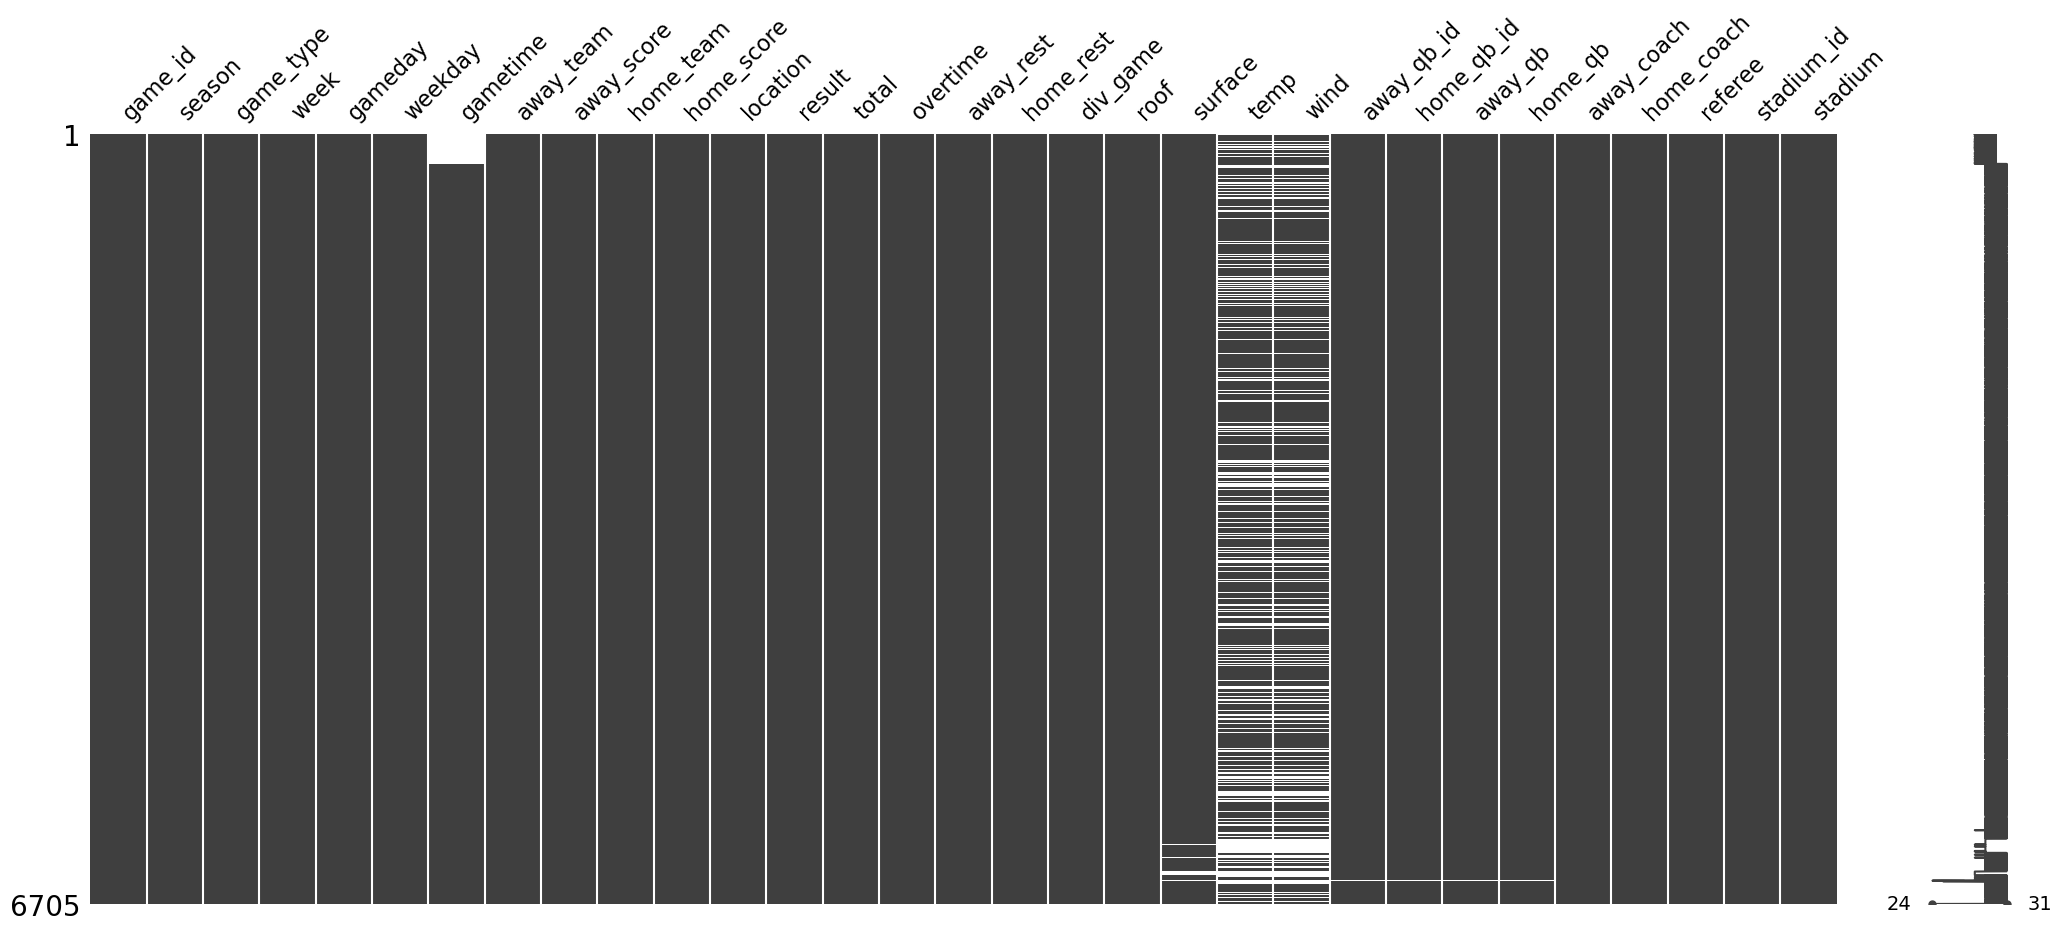

In [12]:
# Missingno NaN overview
msno.matrix(df_msno);
plt.savefig(path + '/media/missing.png', dpi=150)

<Axes: >

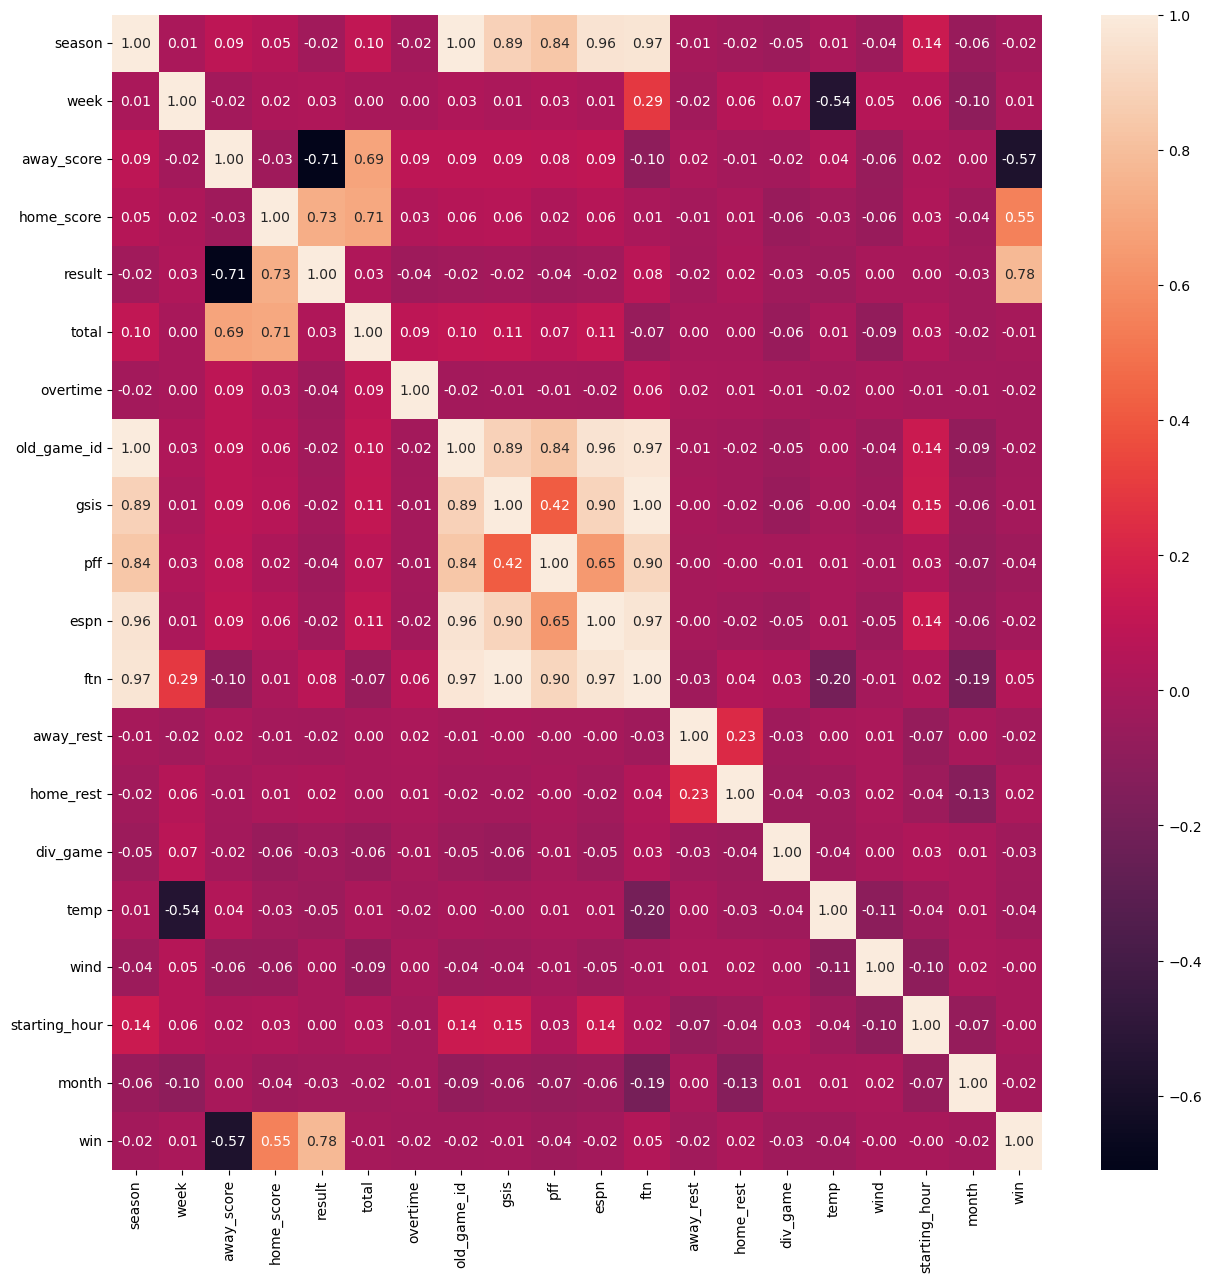

In [13]:
# Clean the DataFrame
df_clean = clean_df(df)
# Split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

# Pairplot
#sns.pairplot(df_clean)

# Create correlation matrix
fig, ax = plt.subplots(figsize=(15, 15))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax)

win
1    3632
0    2814
Name: count, dtype: int64


<Axes: xlabel='win'>

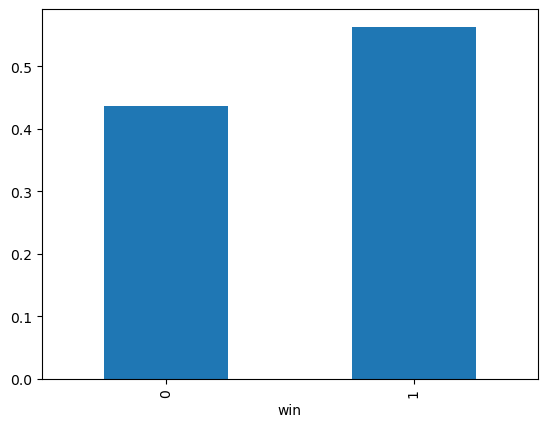

In [14]:
# Check target distribution
print(df_clean["win"].value_counts())
pd.crosstab(index=df_clean["win"], columns="count", normalize="columns").plot(kind="bar", legend=False)

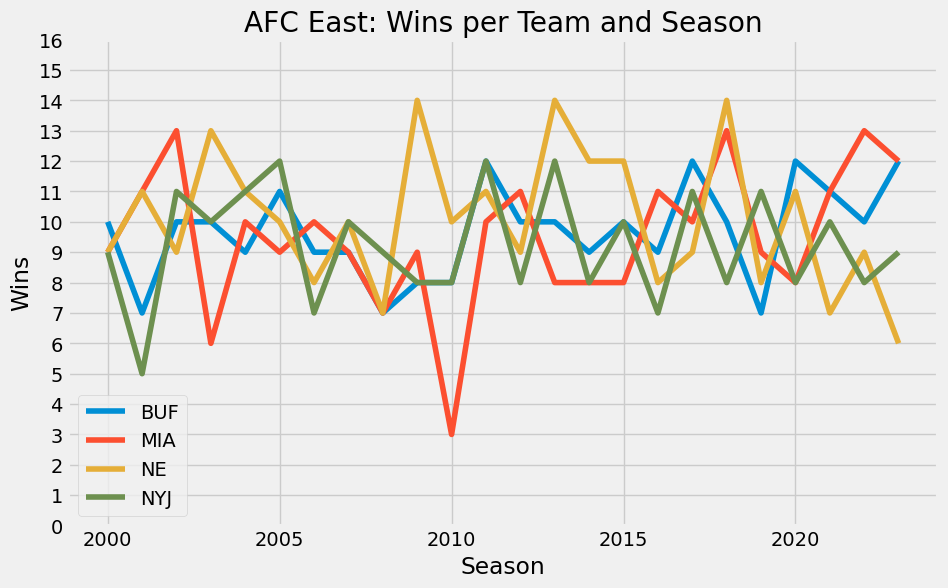

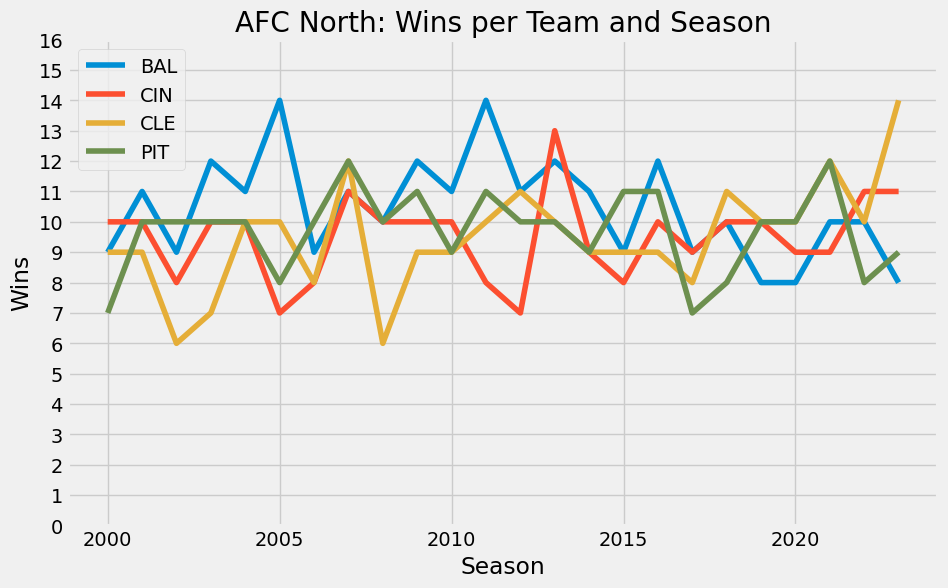

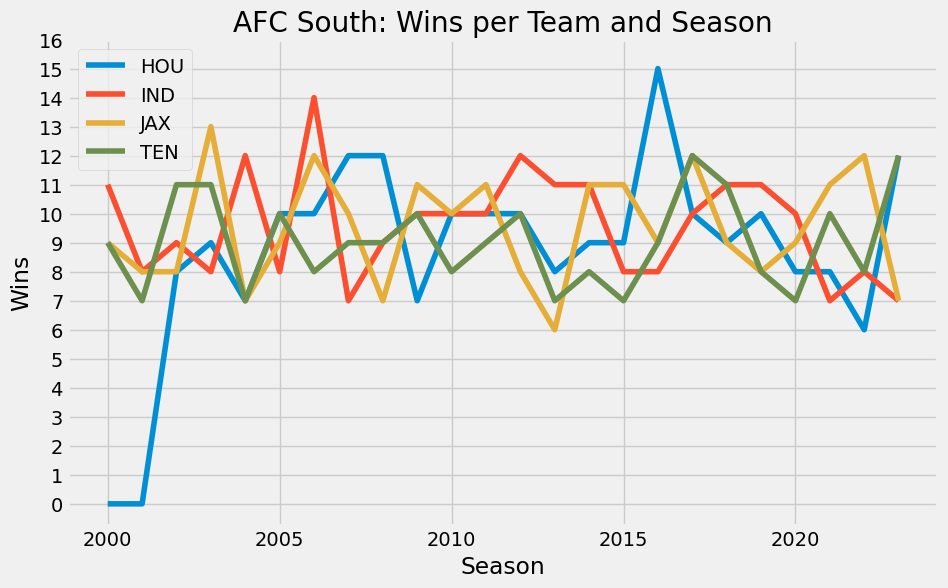

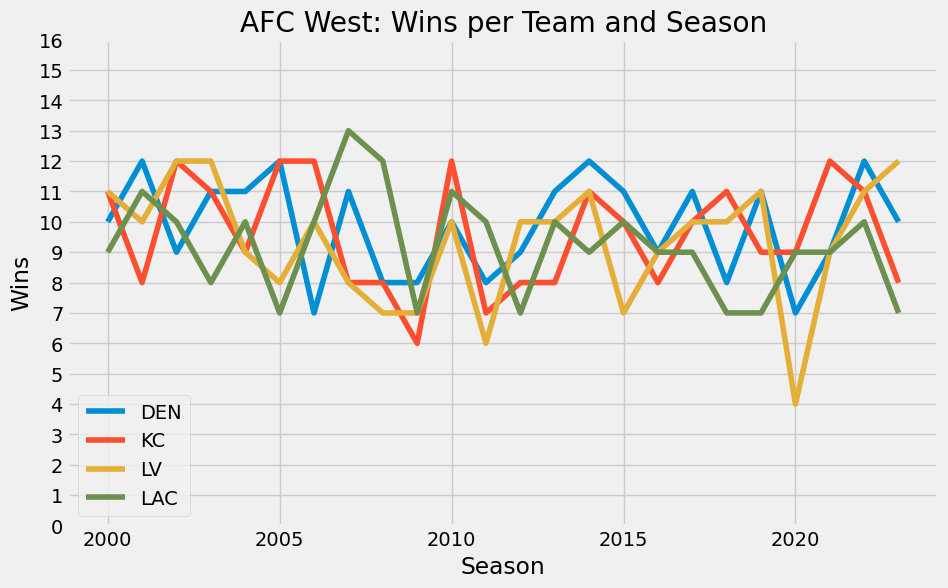

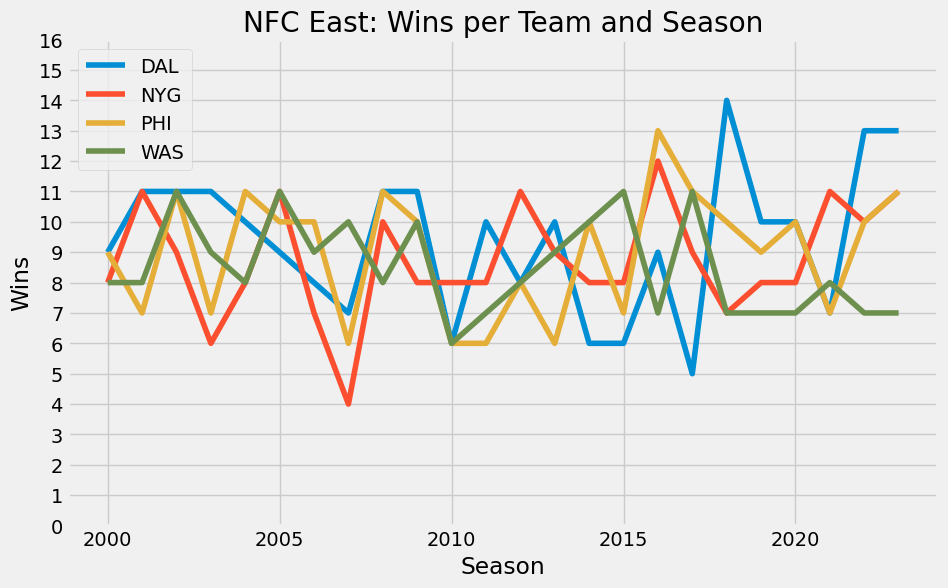

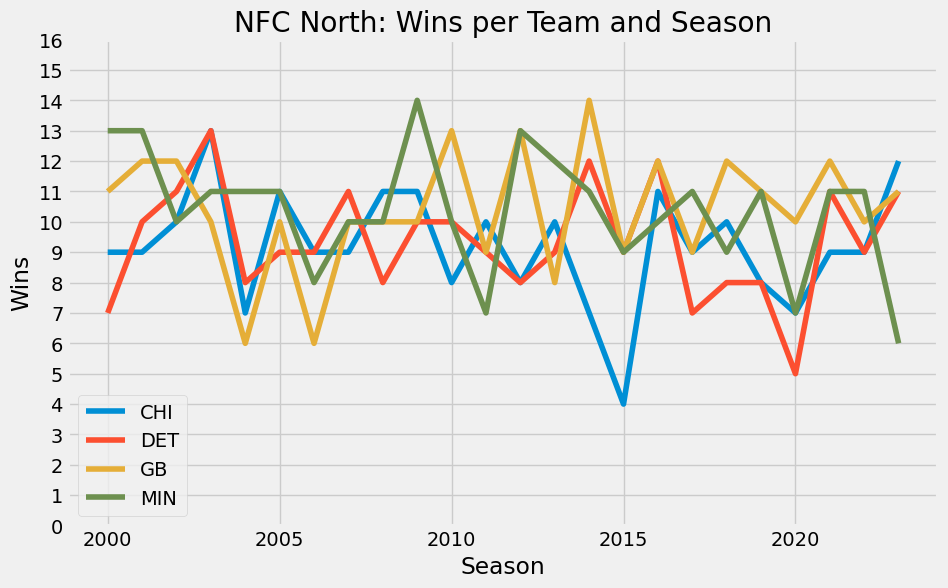

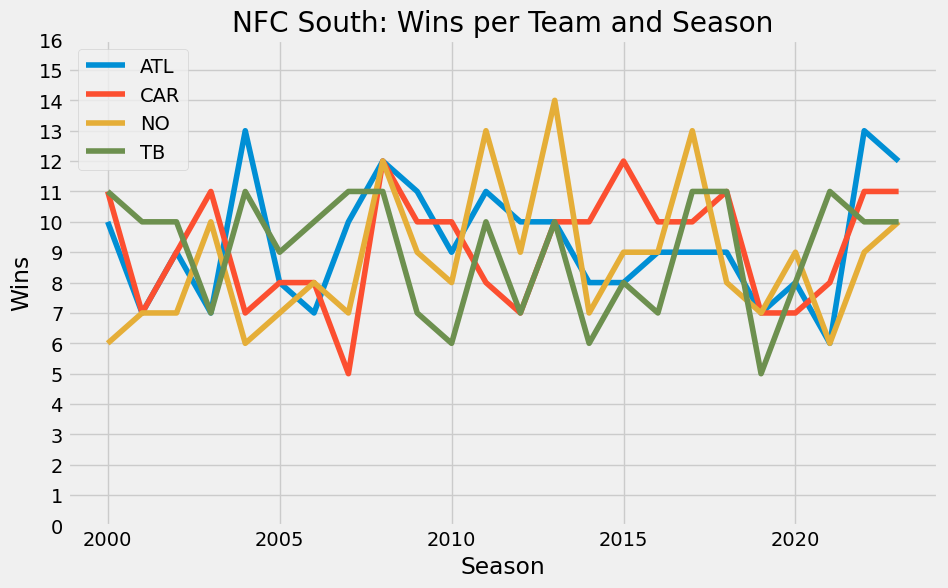

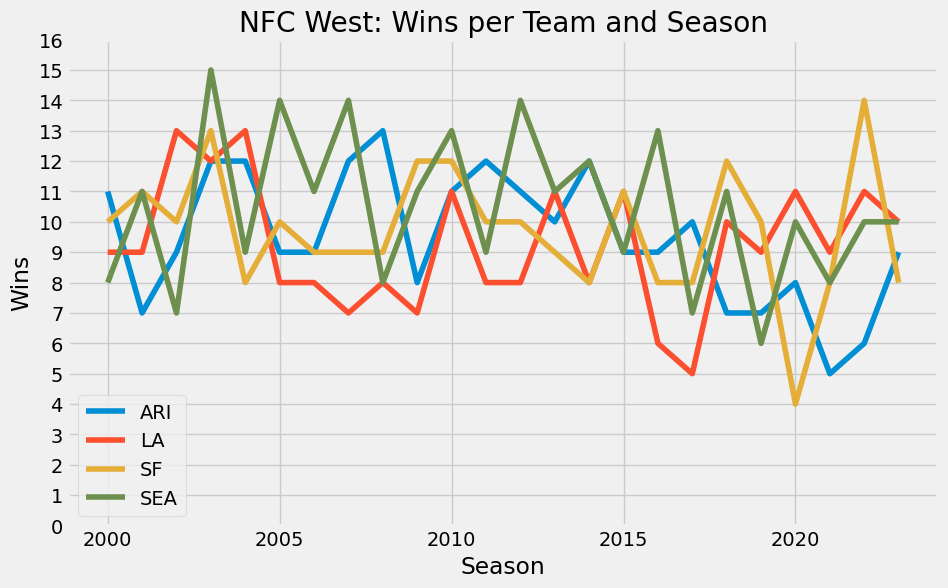

In [15]:
nfl_divisions = [
    # AFC East
    ['BUF', 'MIA', 'NE', 'NYJ'],
    
    # AFC North
    ['BAL', 'CIN', 'CLE', 'PIT'],
    
    # AFC South
    ['HOU', 'IND', 'JAX', 'TEN'],
    
    # AFC West
    ['DEN', 'KC', 'LV', 'LAC'],
    
    # NFC East
    ['DAL', 'NYG', 'PHI', 'WAS'],
    
    # NFC North
    ['CHI', 'DET', 'GB', 'MIN'],
    
    # NFC South
    ['ATL', 'CAR', 'NO', 'TB'],
    
    # NFC West
    ['ARI', 'LA', 'SF', 'SEA']
]
div_names = ["AFC East", "AFC North", "AFC South", "AFC West", "NFC East", "NFC North", "NFC South", "NFC West"]

# Create a new DataFrame to store wins per team
team_wins_season = pd.DataFrame(columns=["team", "wins"])

# Calculate and store wins for each team and season
for team in set(df_clean["away_team"].unique()).union(set(df_clean["home_team"].unique())):
    for season in df_clean["season"].unique():
        total_wins = df_clean[(df_clean["away_team"] == team) & (df_clean["season"] == season)]["win"].sum() + \
                     df_clean[(df_clean["home_team"] == team) & (df_clean["season"] == season)]["win"].sum()
        team_wins_season = pd.concat([team_wins_season, pd.DataFrame({"team": [team], "season": [season], "wins": [total_wins]})], ignore_index=True)

# Sort the DataFrame by wins and season
team_wins_season = team_wins_season.sort_values(by=["team", "season"])

# Plotting
#fig, axs = plt.subplots(nrows=4, ncols=2)
plt.style.use('fivethirtyeight')
i = 0
for div in nfl_divisions:
    plt.figure(figsize=(10, 6))
    for team in div:
        team_data = team_wins_season[team_wins_season["team"] == team]
        plt.plot(team_data["season"], team_data["wins"], label=team)

        plt.title("{}: Wins per Team and Season".format(div_names[i]))
        plt.yticks(range(0, 17, 1))
        plt.xlabel("Season")
        plt.ylabel("Wins")
        plt.legend()
        plt.savefig(path + "/media/{}_Wins_Season.jpg".format(div_names[i], dpi=150))
    i += 1
plt.show()


# Basemodel

In [16]:
df_base = df_clean[['season', 'game_type', 'week', 'away_team', 'home_team', 'location', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]
print(df_base.info())
df_base.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6446 entries, 0 to 6445
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     6446 non-null   int64  
 1   game_type  6446 non-null   object 
 2   week       6446 non-null   int64  
 3   away_team  6446 non-null   object 
 4   home_team  6446 non-null   object 
 5   location   6446 non-null   object 
 6   away_rest  6446 non-null   int64  
 7   home_rest  6446 non-null   int64  
 8   div_game   6446 non-null   int64  
 9   roof       6446 non-null   object 
 10  surface    6446 non-null   object 
 11  temp       6446 non-null   float64
 12  wind       6446 non-null   float64
 13  win        6446 non-null   int32  
dtypes: float64(2), int32(1), int64(5), object(6)
memory usage: 680.0+ KB
None


,season,game_type,week,away_team,home_team,location,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,ATL,Home,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,CLE,Home,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,KC,Home,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,MIN,Home,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,NE,Home,7,7,0,outdoors,grass,71.0,5.0,0


In [17]:
features_train_base, target_train_base, features_test_base, target_test_base = train_test_split(df_base)
features_train_base, features_test_base = pipeline(features_train_base, features_test_base)
features_train_base.head()

,season,week,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.013511,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,1.286128,-0.486579,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,2.095246,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.655814,-1.614715,-0.249337,-0.248942,1.282501,0.153364,0.117697,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.655814,-1.614715,-0.249337,-0.248942,-0.779727,0.814143,-0.694949,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [18]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_base = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="accuracy",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_base.fit(features_train_base, target_train_base)
# Predict Target Test
target_test_base_pred = grid_log_base.predict(features_test_base)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_base.best_params_))
print(classification_report(target_test_base, target_test_base_pred))   

-----LogReg-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.48      0.15      0.23       522
           1       0.54      0.86      0.66       600

    accuracy                           0.53      1122
   macro avg       0.51      0.51      0.45      1122
weighted avg       0.51      0.53      0.46      1122



In [19]:
search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_base = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring="accuracy",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_base.fit(features_train_base, target_train_base)
# Predict Target Test
target_test_base_pred = grid_dtc_base.predict(features_test_base)
# Print Metrics
print("-----DecisionTree -----")
print("Best Parameter: {}".format(grid_dtc_base.best_params_))
print(classification_report(target_test_base, target_test_base_pred))                                             

-----DecisionTree -----
Best Parameter: {'max_depth': 6, 'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.36      0.05      0.08       522
           1       0.53      0.93      0.67       600

    accuracy                           0.52      1122
   macro avg       0.44      0.49      0.38      1122
weighted avg       0.45      0.52      0.40      1122



In [20]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=30, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=20, stop=60, num=10, dtype='int')}

model_rf_base = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_base.fit(features_train_base, target_train_base)
# Predict Target Test
target_test_base_pred = model_rf_base.predict(features_test_base)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf_base.best_params_))
print(classification_report(target_test_base, target_test_base_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 25, 'min_samples_leaf': 32}
              precision    recall  f1-score   support

           0       0.48      0.21      0.29       522
           1       0.54      0.80      0.64       600

    accuracy                           0.53      1122
   macro avg       0.51      0.51      0.47      1122
weighted avg       0.51      0.53      0.48      1122



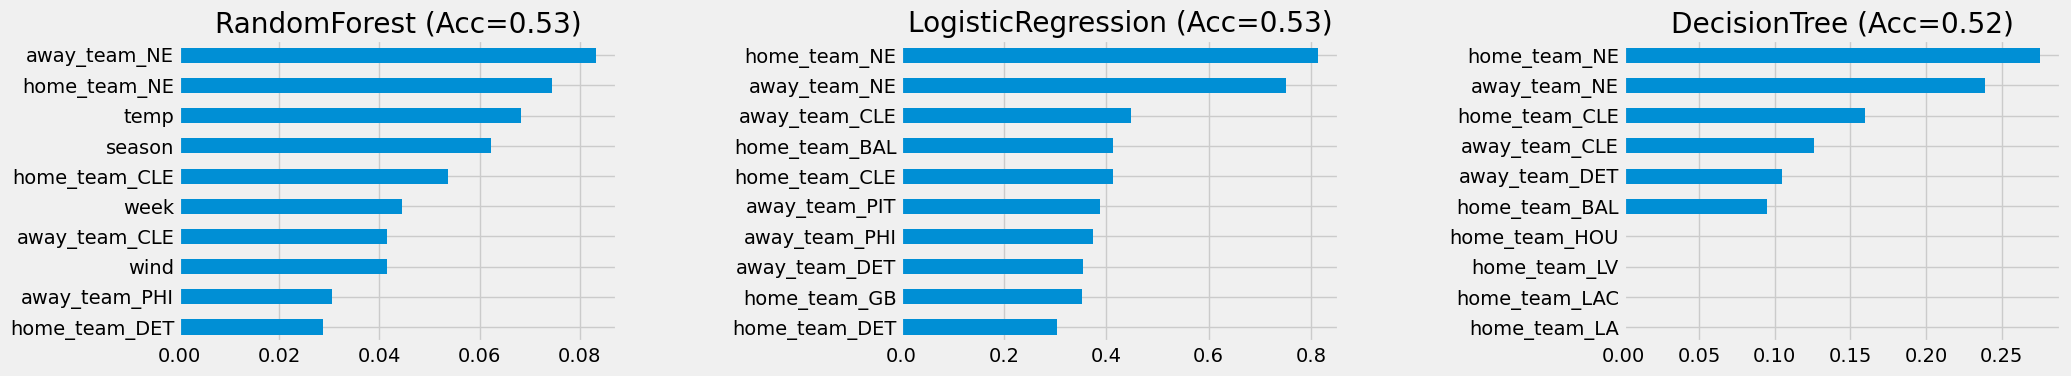

In [21]:
# Feature Importance of the best models
fig, axs = plt.subplots(ncols=3, figsize=(24, 8))
fig.tight_layout(pad=12)

fi_rf_base = model_rf_base.best_estimator_.feature_importances_
feature_importance_rf_base = pd.Series(fi_rf_base, index=features_test_base.columns)
feature_importance_rf_base.sort_values(ascending=False)[:10].plot(kind='barh', title="RandomForest (Acc=0.53)", ax=axs[0]).invert_yaxis()

fi_base = grid_log_base.best_estimator_.coef_[0]
feature_importance_base = pd.Series(np.abs(fi_base), index=features_test_base.columns)
feature_importance_base.sort_values(ascending=False)[:10].plot(kind='barh', title="LogisticRegression (Acc=0.53)", ax=axs[1]).invert_yaxis()

fi_base = grid_dtc_base.best_estimator_.feature_importances_
feature_importance_base = pd.Series(fi_base, index=features_test_base.columns)
feature_importance_base.sort_values(ascending=False)[:10].plot(kind='barh', title="DecisionTree (Acc=0.52)", ax=axs[2]).invert_yaxis()

plt.savefig(path + "/media/Feature_Importances_Base.jpg", dpi=150)

# Feature Engineering

In [22]:
df_eng = feature_eng(df)
df_eng = df_eng.drop(columns=["home_team", "away_team", "away_qb", "home_qb", "away_coach", "home_coach", "referee", "stadium"])
features_train_eng, target_train_eng, features_test_eng, target_test_eng = train_test_split(df_eng)
features_train_eng, features_test_eng = pipeline(features_train_eng, features_test_eng)
features_train_eng.head()

,season,month,week,starting_hour,away_elo,home_elo,away_avg_points,away_avg_points_allowed,home_avg_points,home_avg_points_allowed,away_rest,home_rest,div_game,temp,wind,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.655814,-0.384161,-1.614715,-0.692312,-0.084087,-0.054765,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,0.153364,0.013511,-0.237854,-0.198189,-0.105146,-0.073636,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.655814,-0.384161,-1.614715,-0.692312,-0.084087,-0.054765,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,1.286128,-0.486579,-0.237854,-0.198189,-0.105146,-0.073636,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.655814,-0.384161,-1.614715,-0.692312,-0.084087,-0.054765,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,-0.779727,2.095246,-0.694949,-0.237854,-0.198189,-0.105146,-0.073636,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.655814,-0.384161,-1.614715,-0.692312,-0.084087,-0.054765,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,0.153364,0.117697,-0.237854,-0.198189,-0.105146,-0.073636,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.655814,-0.384161,-1.614715,-0.692312,-0.084087,-0.054765,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,-0.779727,0.814143,-0.694949,-0.237854,-0.198189,-0.105146,-0.073636,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [23]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_eng = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="accuracy",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_eng.fit(features_train_eng, target_train_eng)
# Predict Target Test
target_test_eng_pred = grid_log_eng.predict(features_test_eng)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_eng.best_params_))
print(classification_report(target_test_eng, target_test_eng_pred))   

-----LogReg-----
Best Parameter: {'C': 10, 'penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.60      0.43      0.50       522
           1       0.60      0.76      0.67       600

    accuracy                           0.60      1122
   macro avg       0.60      0.59      0.59      1122
weighted avg       0.60      0.60      0.59      1122



In [24]:
search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_eng = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring="accuracy",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_eng.fit(features_train_eng, target_train_eng)
# Predict Target Test
target_test_eng_pred = grid_dtc_eng.predict(features_test_eng)
# Print Metrics
print("-----DecisionTree -----")
print("Best Parameter: {}".format(grid_dtc_eng.best_params_))
print(classification_report(target_test_eng, target_test_eng_pred))                                             

-----DecisionTree -----
Best Parameter: {'max_depth': 5, 'min_samples_leaf': 250}
              precision    recall  f1-score   support

           0       0.59      0.49      0.53       522
           1       0.61      0.70      0.66       600

    accuracy                           0.60      1122
   macro avg       0.60      0.60      0.59      1122
weighted avg       0.60      0.60      0.60      1122



In [25]:
search_space_rf = {'max_depth': np.geomspace(start=4, stop=100, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=200, num=20, dtype='int')}

model_rf_eng = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_eng.fit(features_train_eng, target_train_eng)
# Predict Target Test
target_test_eng_pred = model_rf_eng.predict(features_test_eng)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf_eng.best_params_))
print(classification_report(target_test_eng, target_test_eng_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 13, 'min_samples_leaf': 28}
              precision    recall  f1-score   support

           0       0.62      0.39      0.48       522
           1       0.60      0.79      0.68       600

    accuracy                           0.60      1122
   macro avg       0.61      0.59      0.58      1122
weighted avg       0.61      0.60      0.59      1122



In [26]:
df_eng_soft = feature_eng(df, alpha=1)
df_eng_soft = df_eng_soft.drop(columns=["home_team", "away_team", "away_qb", "home_qb", "away_coach", "home_coach", "referee", "stadium"])
features_train_eng_soft, target_train_eng_soft, features_test_eng_soft, target_test_eng_soft = train_test_split(df_eng_soft)
features_train_eng_soft, features_test_eng_soft = pipeline(features_train_eng_soft, features_test_eng_soft)
features_train_eng_soft.head()

,season,month,week,starting_hour,away_elo,home_elo,away_avg_points,away_avg_points_allowed,home_avg_points,home_avg_points_allowed,away_rest,home_rest,div_game,temp,wind,away_qb_elo,home_qb_elo,away_coach_elo,home_coach_elo,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.655814,-0.384161,-1.614715,-0.692312,-0.049292,-0.038277,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,0.153364,0.013511,-0.690366,-0.66277,-0.662618,-0.634805,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.655814,-0.384161,-1.614715,-0.692312,-0.049292,-0.038277,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,1.286128,-0.486579,-0.690366,-0.66277,-0.662618,-0.634805,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.655814,-0.384161,-1.614715,-0.692312,-0.049292,-0.038277,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,-0.779727,2.095246,-0.694949,-0.690366,-0.66277,-0.662618,-0.634805,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.655814,-0.384161,-1.614715,-0.692312,-0.049292,-0.038277,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,1.282501,0.153364,0.117697,-0.690366,-0.66277,-0.662618,-0.634805,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.655814,-0.384161,-1.614715,-0.692312,-0.049292,-0.038277,-3.976117,-4.248718,-3.905384,-4.277631,-0.249337,-0.248942,-0.779727,0.814143,-0.694949,-0.690366,-0.66277,-0.662618,-0.634805,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [27]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_eng_soft = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="accuracy",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_eng_soft.fit(features_train_eng_soft, target_train_eng_soft)
# Predict Target Test
target_test_eng_soft_pred = grid_log_eng_soft.predict(features_test_eng_soft)
# Print Metrics
print("-----LogReg | SoftReset-----")
print("Best Parameter: {}".format(grid_log_eng_soft.best_params_))
print(classification_report(target_test_eng_soft, target_test_eng_soft_pred))   

-----LogReg | SoftReset-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.65      0.45      0.53       522
           1       0.62      0.79      0.70       600

    accuracy                           0.63      1122
   macro avg       0.64      0.62      0.61      1122
weighted avg       0.63      0.63      0.62      1122



In [28]:
search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_eng_soft = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring="accuracy",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_eng_soft.fit(features_train_eng_soft, target_train_eng_soft)
# Predict Target Test
target_test_eng_soft_pred = grid_dtc_eng_soft.predict(features_test_eng_soft)
# Print Metrics
print("-----DecisionTree -----")
print("Best Parameter: {}".format(grid_dtc_eng_soft.best_params_))
print(classification_report(target_test_eng_soft, target_test_eng_soft_pred))                                             

-----DecisionTree -----
Best Parameter: {'max_depth': 7, 'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.59      0.45      0.51       522
           1       0.61      0.73      0.66       600

    accuracy                           0.60      1122
   macro avg       0.60      0.59      0.59      1122
weighted avg       0.60      0.60      0.59      1122



In [29]:
search_space_rf = {'max_depth': np.geomspace(start=4, stop=100, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=200, num=20, dtype='int')}

model_rf_eng_soft = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_eng_soft.fit(features_train_eng_soft, target_train_eng_soft)
# Predict Target Test
target_test_eng_soft_pred = model_rf_eng_soft.predict(features_test_eng_soft)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf_eng_soft.best_params_))
print(classification_report(target_test_eng_soft, target_test_eng_soft_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 7, 'min_samples_leaf': 21}
              precision    recall  f1-score   support

           0       0.63      0.42      0.51       522
           1       0.61      0.79      0.69       600

    accuracy                           0.62      1122
   macro avg       0.62      0.61      0.60      1122
weighted avg       0.62      0.62      0.60      1122



In [30]:
df_eng_best = feature_eng(df, alpha=0.8, week_change=4)
df_eng_best = df_eng_best.drop(columns=["home_team", "away_team", "away_qb", "home_qb", "away_coach", "home_coach", "referee", "stadium"])
features_train_eng_best, target_train_eng_best, features_test_eng_best, target_test_eng_best = train_test_split(df_eng_best, split_season=2023)
features_train_eng_best, features_test_eng_best = pipeline(features_train_eng_best, features_test_eng_best)

param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_eng_best = GridSearchCV(LogisticRegression(max_iter=5000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="accuracy",
                                               n_jobs=-1)
# Fit on Train Data
grid_log_eng_best.fit(features_train_eng_best, target_train_eng_best)
# Predict Target Test
target_test_eng_best_pred = grid_log_eng_best.predict(features_test_eng_best)
# Print Metrics
print("-----LogReg (alpha = 0.8, week = 4)-----")
print("Best Parameter: {}".format(grid_log_eng_best.best_params_))
print(classification_report(target_test_eng_best, target_test_eng_best_pred))   

-----LogReg (alpha = 0.8, week = 4)-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.61      0.52      0.56       125
           1       0.66      0.74      0.70       159

    accuracy                           0.64       284
   macro avg       0.63      0.63      0.63       284
weighted avg       0.64      0.64      0.64       284



In [31]:
search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_eng_best = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring="accuracy",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_eng_best.fit(features_train_eng_best, target_train_eng_best)
# Predict Target Test
target_test_eng_best_pred = grid_dtc_eng_best.predict(features_test_eng_best)
# Print Metrics
print("-----DecisionTree -----")
print("Best Parameter: {}".format(grid_dtc_eng_best.best_params_))
print(classification_report(target_test_eng_best, target_test_eng_best_pred))                                       

-----DecisionTree -----
Best Parameter: {'max_depth': 8, 'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.60      0.45      0.51       125
           1       0.64      0.76      0.69       159

    accuracy                           0.62       284
   macro avg       0.62      0.60      0.60       284
weighted avg       0.62      0.62      0.61       284



In [32]:
search_space_rf = {'max_depth': np.geomspace(start=4, stop=100, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=200, num=10, dtype='int')}

model_rf_eng_best = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50,
                                                         random_state=42),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_eng_best.fit(features_train_eng_best, target_train_eng_best)
# Predict Target Test
target_test_eng_best_pred = model_rf_eng_best.predict(features_test_eng_best)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf_eng_best.best_params_))
print(classification_report(target_test_eng_best, target_test_eng_best_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 8, 'min_samples_leaf': 111}
              precision    recall  f1-score   support

           0       0.63      0.46      0.53       125
           1       0.65      0.79      0.71       159

    accuracy                           0.64       284
   macro avg       0.64      0.63      0.62       284
weighted avg       0.64      0.64      0.63       284



In [33]:
# the best rf model for real 
df_eng_best_fr = feature_eng(df, alpha=0.7, week_change=1)
df_eng_best_fr = df_eng_best_fr.drop(columns=["home_team", "away_team", "away_qb", "home_qb", "away_coach", "home_coach", "referee", "stadium"])
features_train_eng_best_fr, target_train_eng_best_fr, features_test_eng_best_fr, target_test_eng_best_fr = train_test_split(df_eng_best_fr, split_season=2023)
features_train_eng_best_fr, features_test_eng_best_fr = pipeline(features_train_eng_best_fr, features_test_eng_best_fr)

#search_space_rf = {'max_depth': np.geomspace(start=4, stop=100, num=10, dtype='int'),
#                   'min_samples_leaf': np.geomspace(start=1, stop=200, num=10, dtype='int')}

# Smaller search space
search_space_rf = {'max_depth': [10, 16],
                   'min_samples_leaf': [34, 36]}

model_rf_eng_best_fr = GridSearchCV(estimator=RandomForestClassifier(n_estimators=100,
                                                                     random_state=42),
                                                                     param_grid=search_space_rf,
                                                                     scoring='accuracy',
                                                                     cv=5,
                                                                     n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf_eng_best_fr.fit(features_train_eng_best_fr, target_train_eng_best_fr)
# Predict Target Test
target_test_eng_best_fr_pred = model_rf_eng_best_fr.predict(features_test_eng_best_fr)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf_eng_best_fr.best_params_))
print(classification_report(target_test_eng_best_fr, target_test_eng_best_fr_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 16, 'min_samples_leaf': 34}
              precision    recall  f1-score   support

           0       0.65      0.51      0.57       125
           1       0.67      0.79      0.72       159

    accuracy                           0.67       284
   macro avg       0.66      0.65      0.65       284
weighted avg       0.66      0.67      0.66       284



In [34]:
model_rf_eng_best_fr = RandomForestClassifier(max_depth=16,
                                              min_samples_leaf=34,
                                              n_estimators=100,
                                              random_state=42)
# Fit on Train Data
model_rf_eng_best_fr.fit(features_train_eng_best_fr, target_train_eng_best_fr)
# Predict Target Test
target_test_eng_best_fr_pred = model_rf_eng_best_fr.predict(features_test_eng_best_fr)
# Print Metrics
print("-----RandomForest-----")
#print("Best Parameter: {}".format(model_rf_eng_best_fr.best_params_))
print(classification_report(target_test_eng_best_fr, target_test_eng_best_fr_pred))

-----RandomForest-----
              precision    recall  f1-score   support

           0       0.65      0.51      0.57       125
           1       0.67      0.79      0.72       159

    accuracy                           0.67       284
   macro avg       0.66      0.65      0.65       284
weighted avg       0.66      0.67      0.66       284



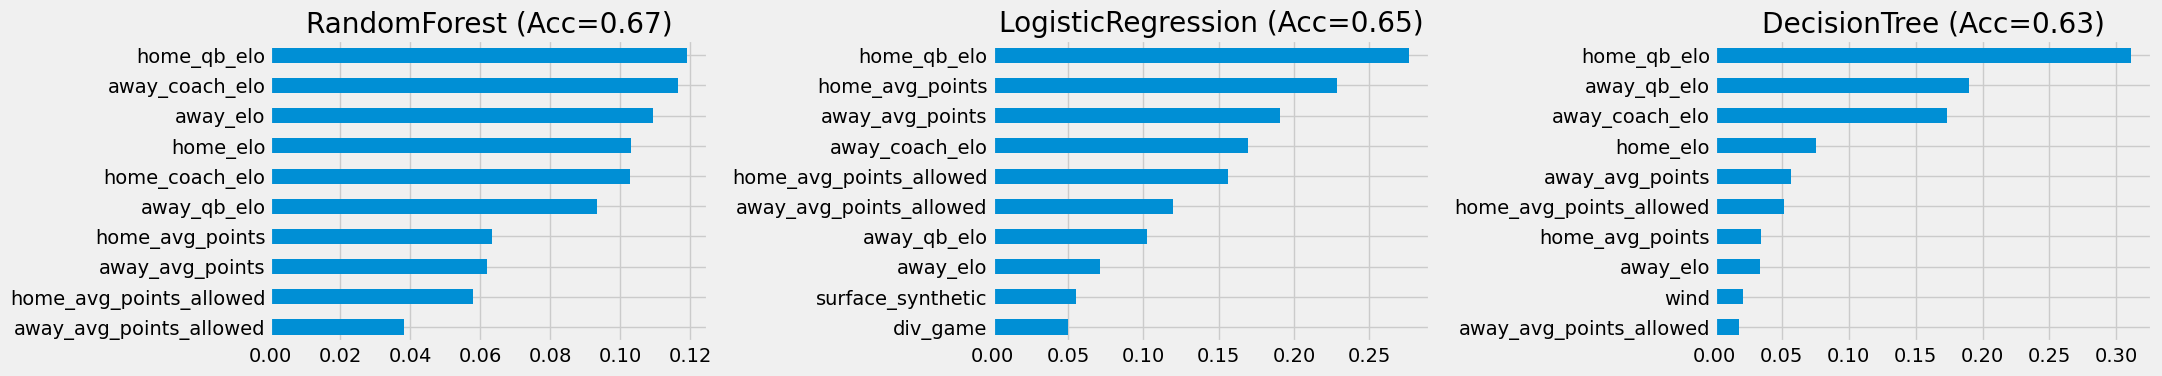

In [35]:
# Feature Importance of the best models
fig, axs = plt.subplots(ncols=3, figsize=(24, 8))
fig.tight_layout(pad=12)

fi_rf_best = model_rf_eng_best_fr.feature_importances_
feature_importance_rf_best = pd.Series(fi_rf_best, index=features_test_eng_best_fr.columns)
feature_importance_rf_best.sort_values(ascending=False)[:10].plot(kind='barh', title="RandomForest (Acc=0.67)", ax=axs[0]).invert_yaxis()

fi_log = grid_log_eng_best.best_estimator_.coef_[0]
feature_importance_log = pd.Series(np.abs(fi_log), index=features_test_eng_best.columns)
feature_importance_log.sort_values(ascending=False)[:10].plot(kind='barh', title="LogisticRegression (Acc=0.65)", ax=axs[1]).invert_yaxis()

fi_dtc = grid_dtc_eng_best.best_estimator_.feature_importances_
feature_importance_dtc = pd.Series(fi_dtc, index=features_test_eng_best.columns)
feature_importance_dtc.sort_values(ascending=False)[:10].plot(kind='barh', title="DecisionTree (Acc=0.63)", ax=axs[2]).invert_yaxis()

plt.savefig(path + "/media/Feature_Importances_Engineered.jpg", dpi=150)

# Predicted Result

In [36]:
target_test_eng_best_fr_pred_proba = model_rf_eng_best_fr.predict_proba(features_test_eng_best_fr)

In [37]:
df_2023_pred = df.loc[df["season"] == 2023]

In [39]:
df_2023_pred.loc[:, "away_%"] = target_test_eng_best_fr_pred_proba[:, 0]
df_2023_pred.loc[:, "home_%"] = target_test_eng_best_fr_pred_proba[:, 1]
df_2023_pred = df_2023_pred[["season", "week", "weekday", "game_type", "away_team", "home_team", "away_%", "home_%"]]
df_2023_pred.tail()

,season,week,weekday,game_type,away_team,home_team,away_%,home_%
6700,2023,20,Saturday,DIV,GB,SF,0.318650,0.681350
6701,2023,20,Sunday,DIV,TB,DET,0.349699,0.650301
6702,2023,20,Sunday,DIV,KC,BUF,0.374685,0.625315
6703,2023,21,Sunday,CON,KC,BAL,0.383855,0.616145
6704,2023,21,Sunday,CON,DET,SF,0.403532,0.596468
